# Per-variant temporal selection coefficient `s` — SV purging and its climate gradient

**`s`** = per-variant **plot-replicate selection coefficient** at a site = mean over the site's
~10–12 replicate plots of the OLS slope of $\mathrm{logit}(p)$ on generation (gen 0 = shared founding
frequency). Plots-as-replicates separate real selection (consistent direction across independent
plots) from drift. `s<0` = declining (purged), `s>0` = rising (favoured). Variants pass a founder-panel
filter (minor-allele count 12–219, call-rate ≥ 0.9) and a seed-mix boundary filter
(0.02 ≤ $p_0$ ≤ 0.98).

**De-trending.** Raw median `s` vs $p_0$ carries a logit/boundary (Jensen) artifact, amplified for
rare variants sitting on few founders. Each curve subtracts the per-$p_0$-bin **SNP** median (SNPs =
the abundant, ~neutral reference class), so it shows $s_{\text{class}} - s_{\text{SNP}}$ at matched
$p_0$: SNP ≡ 0 by construction, below 0 = more purged than a same-frequency SNP.

**Result — one finding with two faces:**
1. **No net, genome-wide shift (null).** Averaged over sites the de-trended SV excess is ≈ 0 (median
   **+0.0004**, negative at only **15/31 sites**, sign test n.s.). SVs are *not* uniformly more purged
   than same-frequency SNPs.
2. **But SV purging is climate-graded (real).** The same per-site de-trended shift tracks climate —
   stronger SV purging at **hot** (bio1 ρ ≈ −0.48, p ≈ 0.006) and **dry-summer / arid** (bio18
   ρ ≈ +0.65, p < 0.001) sites, ≈ 0 or positive at cold/wet ones. The net-null in (1) is
   warm-negative and cold-positive sites cancelling; the real signal is the **gradient**, and (per the
   panel grid) it sits in the rare (low-$p_0$) tail at the warm sites. The insertion/deletion panel
   further splits the SV curve by polarity.

**Scope (trimmed 2026-07-20).** This notebook is the headline only — the de-trended per-site grids
(all-class, and insertions-vs-deletions) and the climate scatter. The finer analyses that localize
this *same* signal to the purged tail (ECDF-difference, shift-function), formalize the per-variant
climate slope β, and test its robustness to de-trending, plus the parallelism/PicMin arm, live in
`SV_TEMPORAL_PURGING_SUMMARY.md` (this notebook was consolidated from 7 earlier ones; the removed
sections are recoverable from git history). Those are alternate views / refinements of the one
climate-graded, tail-concentrated purging signal, not independent findings.

**Standing caveats (apply to the climate-graded result):**
- **Hitchhiking.** Global-mode kMate AF is a founder-mixture projection — cannot separate SV-specific
  selection from hitchhiking on a climate-purged haplotype (`GLOBAL_MODE_DECISION.md`). Local/window
  mode is not a clean fix (panel-incompleteness artifacts are deterministic and replicate-reproducible,
  and would masquerade as this exact signal).
- **Insertion-polarity.** The purging is insertion-specific (reference-relative; see the ins/del
  panel). Ruled out as a within-panel calling-confidence artifact (`F_MISSING`/`MA` checks), but not
  equivalent to true ancestral polarization — no outgroup exists in this repo. A *systematic*
  reference/mapping-bias version of this caveat remains open.

See `SV_TEMPORAL_PURGING_SUMMARY.md` for the full audit narrative.

In [1]:

import os
import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
plt.rcParams.update({'figure.dpi':110, 'font.size':8, 'axes.linewidth':0.6})
G = "/global/scratch/users/tbellg/kmate/analysis/grenenet_selection/sv_adaptive"
PLOTS = "/global/scratch/users/tbellg/kmate/analysis/grenenet_selection/notebooks/plots"  # figures saved here
os.makedirs(PLOTS, exist_ok=True)
COL = {"SNP":"#888888", "indel":"#0072B2", "SV":"#D55E00", "ins":"#D55E00", "del":"#009E73"}
rng = np.random.default_rng(0)
NBIN_MATCH, NDRAW = 25, 20000   # frequency-matching resample granularity, shared by all sections

def match_to(target_p0, src_s, src_p0):
    # resample src_s so its p0 distribution matches target_p0 (bin-stratified, with replacement)
    e = np.quantile(np.concatenate([target_p0, src_p0]), np.linspace(0, 1, NBIN_MATCH + 1)); e[-1] += 1e-9
    tb = np.digitize(target_p0, e[1:-1]); sb = np.digitize(src_p0, e[1:-1]); out = []
    for b in range(NBIN_MATCH):
        k = int(round((tb == b).mean() * NDRAW)); pool = src_s[sb == b]
        if k > 0 and pool.size: out.append(rng.choice(pool, k, replace=True))
    return np.concatenate(out) if out else np.array([])

# shared data: per-site raw (s, p0) subsamples for SNP/indel/SV (all SV; 25k SNP/indel subsample),
# the shared p0-decile bin edges, and the per-(site,stratum,class) de-trending baseline
npz = np.load(f"{G}/s_dist_by_stratum.npz")
long = pd.read_csv(f"{G}/s_dist_by_stratum.csv")
long["resid"] = long["median"] - long["base"]
meta = pd.read_csv(f"{G}/s_dist_by_stratum_sitemeta.csv")
meta = meta.merge(pd.read_csv(f"{G}/s_climate_slope_sign_by_site.csv")[["site","bio18"]], on="site", how="left")
meta = meta.sort_values("bio1").reset_index(drop=True)
p0q = npz["p0q"]; mids = 0.5 * (p0q[:-1] + p0q[1:]); NBIN = len(p0q) - 1
binf = lambda p: np.clip(np.digitize(p, p0q[1:-1]), 0, NBIN - 1)
base_lookup = long.set_index(["site", "stratum"])["base"].to_dict()
sites_npz = sorted({int(k.split("_")[0]) for k in npz.files if k.split("_")[0].isdigit()})
print(f"{len(meta)} sites, {long.stratum.nunique()} initial-frequency strata")


31 sites, 10 initial-frequency strata


## De-trended per-site `s`, and its climate gradient

Raw median `s` vs $p_0$ has a strong NEG→POS slope that is an artifact of the logit statistic at the
0/1 boundaries (reproduced by a zero-selection drift simulation; median *linear* $\Delta p$ stays
~0), amplified because rare variants sit on few founders (small effective $N_e$). We subtract the
per-$p_0$-bin **SNP** median (SNPs are the abundant, ~neutral reference class that defines the
artifact's shape), so every curve/point shows $s_{\text{class}} - s_{\text{SNP}}$ at matched $p_0$:
SNP ≡ 0 by construction; **below 0 = more purged than a same-frequency SNP.** (SNPs are 81% of all
variants and indels behave like SNPs, so this SNP baseline ≈ the full-population all-class median, but
is not distorted by the purged SVs the way an equal-count SNP/indel/SV subsample pool would be.)

Three views follow, all on this de-trended shift:
1. **Per-site panel grid** — SV / indel / SNP curves vs $p_0$ (log x), one site per panel, ordered
   cold→hot. Watch the low-$p_0$ (rare) tail at the warm sites.
2. **Insertion-vs-deletion grid** — the same grid, splitting the SV curve by polarity (ref-relative):
   insertions vs deletions, to see which carries the tail purging.
3. **Climate scatter** — each site's mean de-trended shift vs bio1 (temperature) and bio18 (dry-summer
   precip). This is where the climate gradient shows up as a single number per axis.

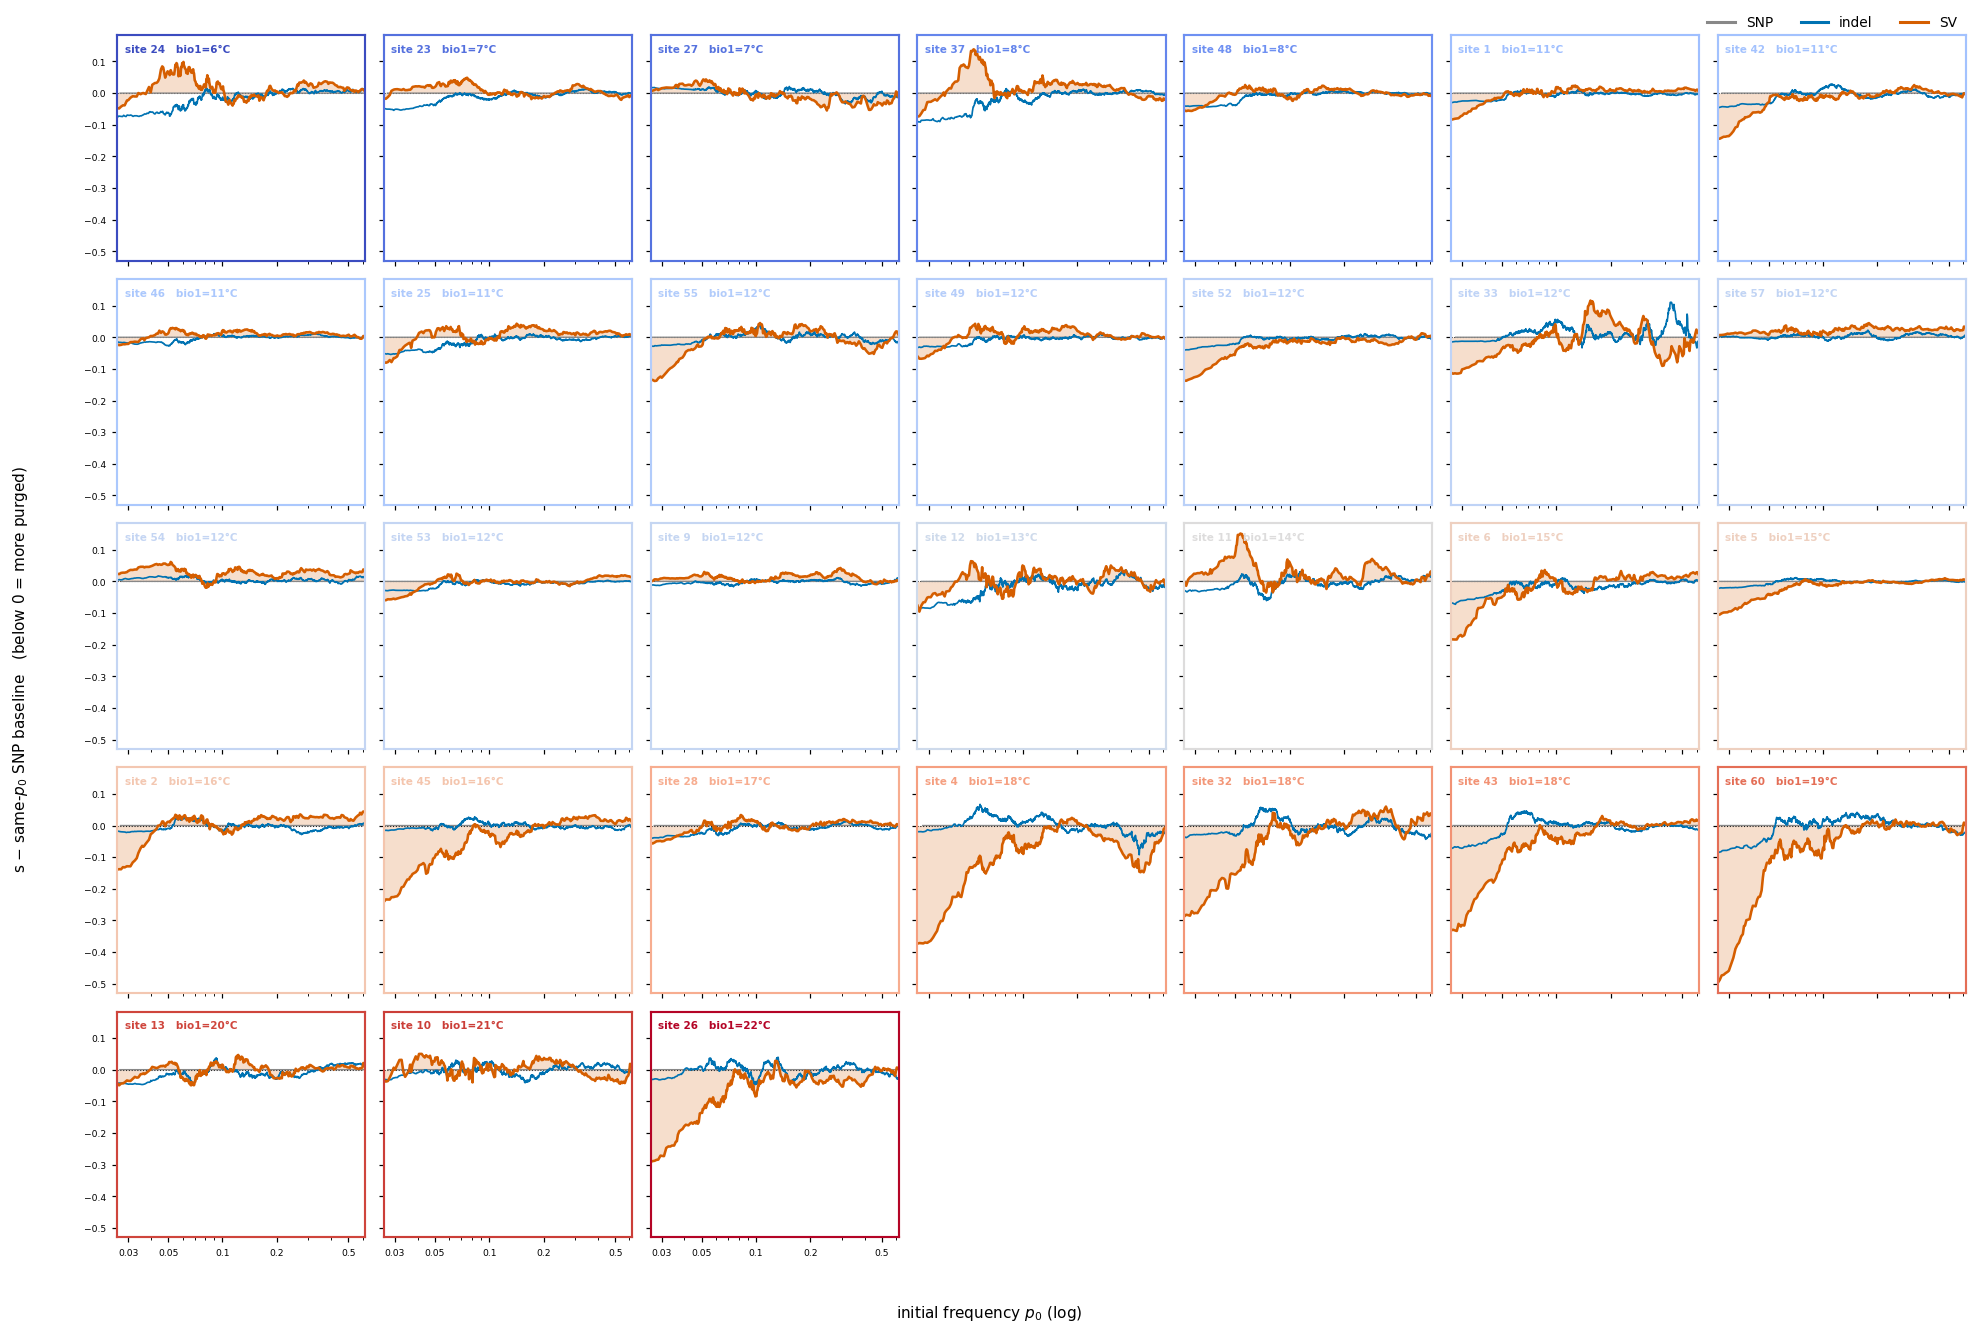

saved /global/scratch/users/tbellg/kmate/analysis/grenenet_selection/notebooks/plots/s_distribution_by_site.png  (shared ylim=(-0.5291784874107245, 0.18369317626376577), true data min/max -- no clipping)


In [2]:

# per-site curves via a sliding window over raw (s, p0) pairs (not the disjoint deciles in `long`) --
# a fixed-count window adapts to local density, so the SV line stays smooth where SV is sparse instead
# of getting noisier there.
def rolling_curve(s, p0, thin=15):
    o = np.argsort(p0); p0s, ss = p0[o], s[o]
    win = max(51, len(ss)//8); win += 1 - win%2  # odd
    med = pd.Series(ss).rolling(win, center=True, min_periods=win//3).median().to_numpy()
    return p0s[::thin], med[::thin]

def site_curves(site):
    # SNP-ONLY baseline: SNP is the abundant, ~neutral reference class, so the per-p0 logit/boundary
    # offset is estimated from SNPs alone (consistent with the CSV `base` + Section 4, and with
    # Sections 2-3's SNP-matching). SNP then reads exactly 0 by construction; SV/indel read as
    # excess-vs-SNP. (Superseded the earlier balanced-subsample all-class pool, which incidentally
    # over-weighted SVs ~24x their genomic share and let purged SVs contaminate their own baseline.)
    p0_base, base_curve = rolling_curve(npz[f"{site}_s_SNP"], npz[f"{site}_p0_SNP"])
    logp0_base = np.log(p0_base)
    out = {}
    for c in ["SNP","indel","SV"]:
        p0c, medc = rolling_curve(npz[f"{site}_s_{c}"], npz[f"{site}_p0_{c}"])
        out[c] = (p0c, medc - np.interp(np.log(p0c), logp0_base, base_curve))
    return out

XTICKS = [0.03, 0.05, 0.1, 0.2, 0.5]; XLIM = (0.026, 0.62)
sites = meta.site.tolist()
curves = {s: site_curves(s) for s in sites}

# Shared y-limit, sized to the TRUE min/max (not a percentile guess) so no panel ever clips --
# a fixed guess clipped 19/31 panels, and a percentile-based range still clipped 10/31 (a few
# sites' rolling curve genuinely swings to +-0.2-0.4 right at the lowest p0, the rare-founder
# logit/boundary artifact the Section 1 takeaway describes). Using the actual full range keeps
# the shared scale (for direct cross-panel comparison) while guaranteeing every curve fits.
def _visible(p0c, rc):
    m = (p0c >= XLIM[0]) & (p0c <= XLIM[1]); return p0c[m], rc[m]
all_vis = np.concatenate([np.concatenate([_visible(*curves[s][cl])[1] for s in sites]) for cl in ["SV","indel"]])
pad = 0.05 * (all_vis.max() - all_vis.min())
YLIM = (all_vis.min() - pad, all_vis.max() + pad)

ncol, nrow = 7, int(np.ceil(len(sites)/7))
norm = mpl.colors.Normalize(vmin=meta.bio1.min(), vmax=meta.bio1.max()); cmap = mpl.cm.coolwarm
fig, axes = plt.subplots(nrow, ncol, figsize=(18, 2.4*nrow), sharex=True, sharey=True)
axes = axes.ravel()
for ax in axes[len(sites):]: ax.axis("off")
for i, s in enumerate(sites):
    ax = axes[i]; cv = curves[s]
    p0sv, rsv = _visible(*cv["SV"]); p0in, rin = _visible(*cv["indel"]); p0sn, rsn = _visible(*cv["SNP"])
    ax.axhline(0, color="k", lw=0.7, ls=":")
    ax.fill_between(p0sv, 0, rsv, color=COL["SV"], alpha=0.20, lw=0)
    ax.plot(p0sn, rsn, "-", color=COL["SNP"], lw=0.9)
    ax.plot(p0in, rin, "-", color=COL["indel"], lw=1.1)
    ax.plot(p0sv, rsv, "-", color=COL["SV"], lw=1.7)
    b1 = meta.bio1.iloc[i]; c = cmap(norm(b1))
    ax.annotate(f"site {int(meta.site.iloc[i])}   bio1={b1:.0f}°C", xy=(0.03,0.96),
                xycoords="axes fraction", va="top", ha="left", fontsize=6.8, color=c, fontweight="bold")
    for sp in ax.spines.values(): sp.set_color(c); sp.set_linewidth(1.4)
    ax.set_xscale("log"); ax.set_xlim(*XLIM); ax.set_xticks(XTICKS)
    ax.set_xticklabels([str(t) for t in XTICKS], fontsize=6)
    ax.tick_params(labelsize=6)
axes[0].set_ylim(*YLIM)
fig.supxlabel("initial frequency $p_0$ (log)", y=0.005, fontsize=10)
fig.supylabel("s − same-$p_0$ SNP baseline   (below 0 = more purged)", x=0.006, fontsize=10)
fig.legend(handles=[Line2D([0],[0],color=COL[c],lw=2,label=c) for c in ["SNP","indel","SV"]],
           loc="upper right", ncol=3, fontsize=9, frameon=False, bbox_to_anchor=(0.995,1.004))
fig.tight_layout(rect=[0.02,0.02,1,0.99])
fig.savefig(f"{PLOTS}/s_distribution_by_site.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"saved {PLOTS}/s_distribution_by_site.png  (shared ylim={YLIM}, true data min/max -- no clipping)")


### Insertions vs deletions

Same de-trended per-site grid, but the SV curve is split by **polarity** (ref-relative length):
**insertions** (alt longer than ref, orange) vs **deletions** (ref longer, green), each still shown as
$s_{\text{class}} - s_{\text{SNP}}$ vs $p_0$. Tests whether the warm-site rare-tail purging seen in
the all-class grid is carried by one polarity. (`sv_isdel` comes from `s_climate_slope.npz`; it is
aligned to the SV column order of `s_dist_by_stratum.npz` — the two share the same filters/order —
and the cell asserts that alignment before plotting.)

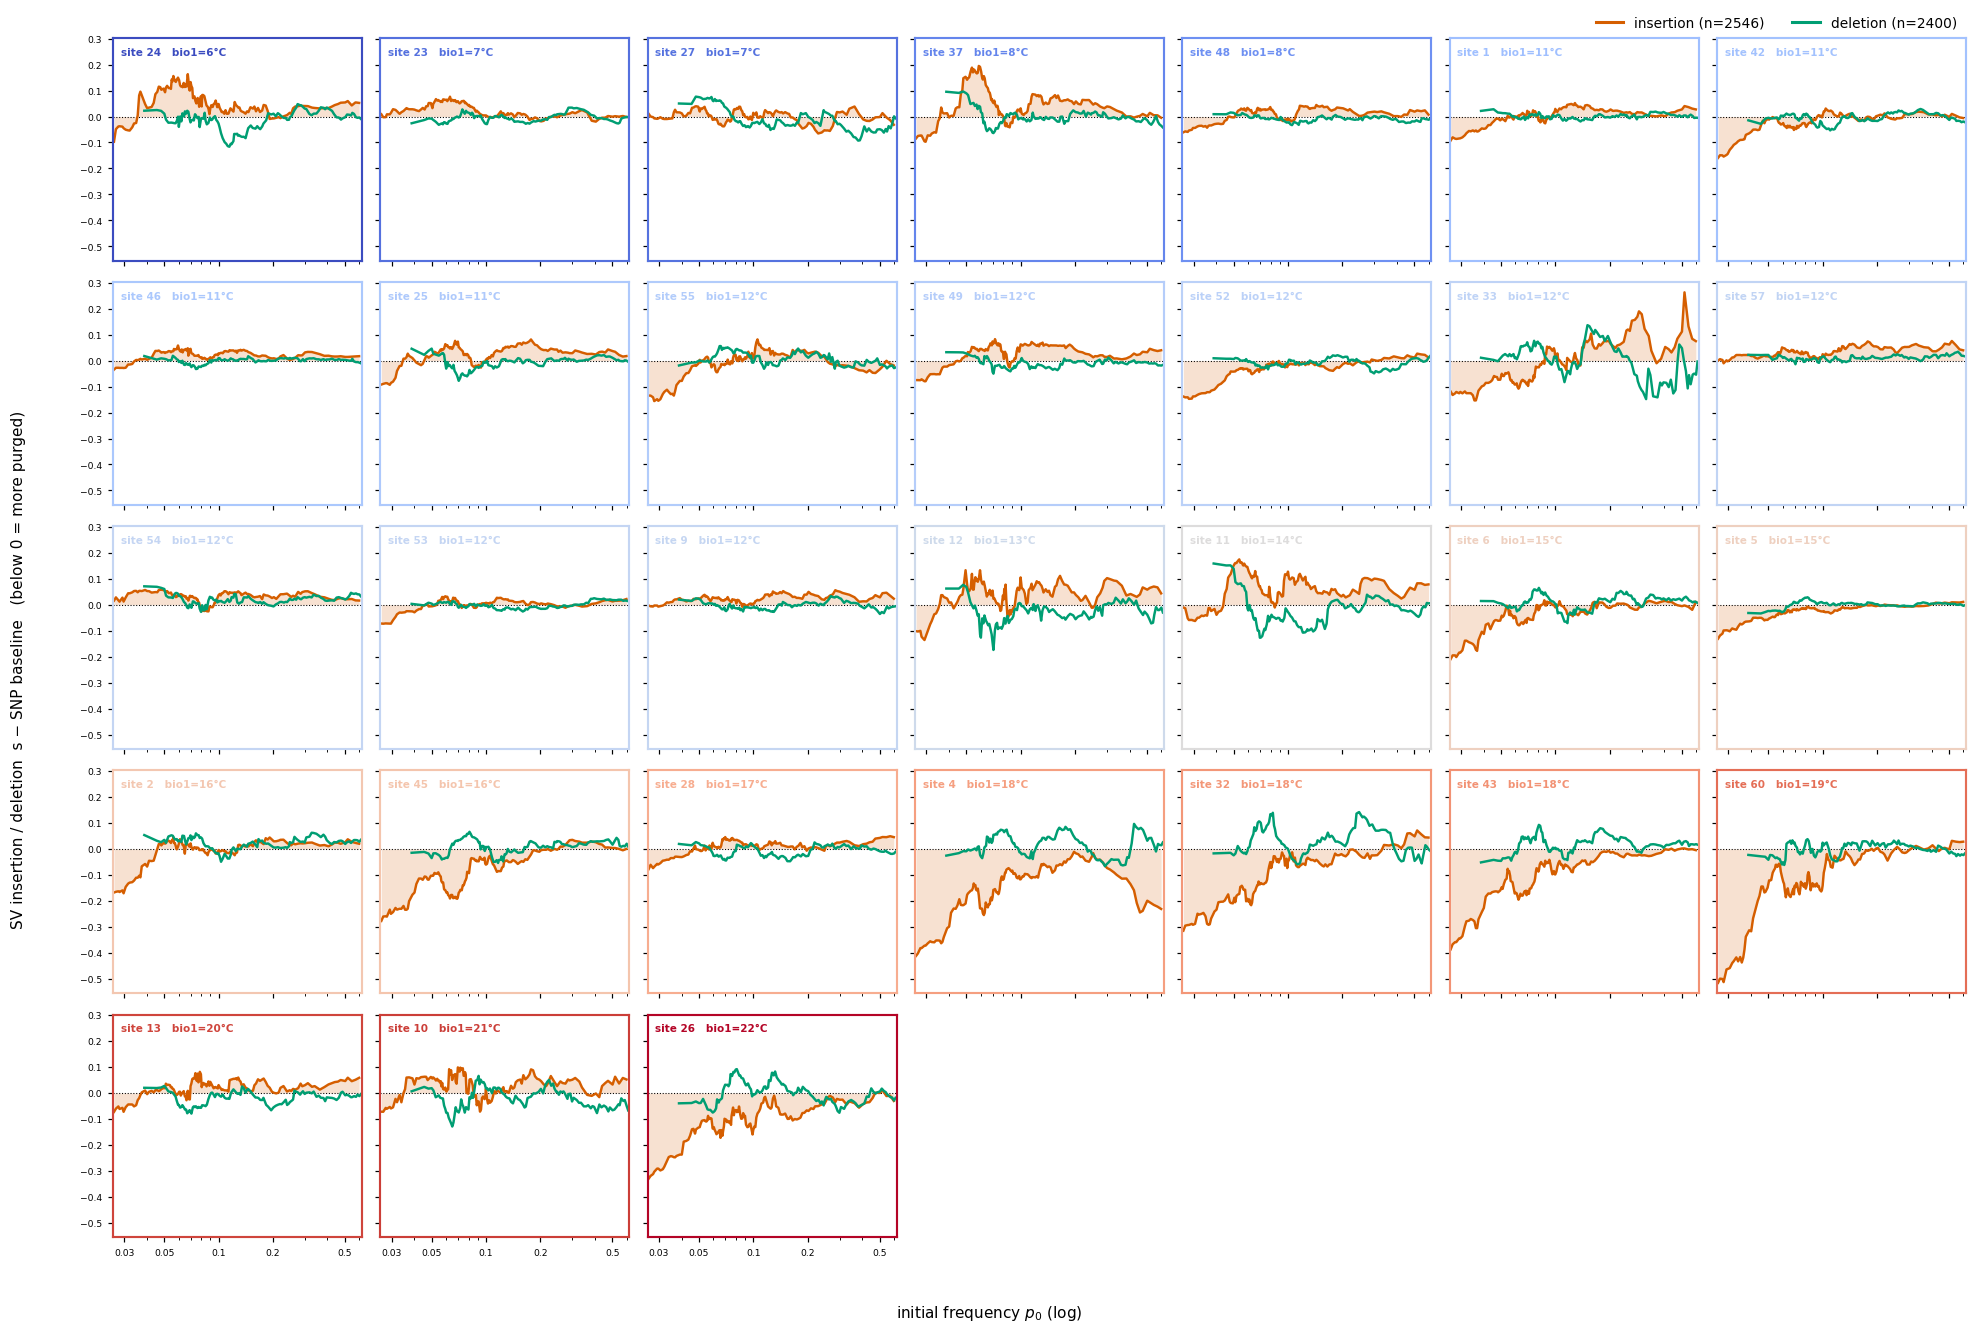

saved /global/scratch/users/tbellg/kmate/analysis/grenenet_selection/notebooks/plots/s_distribution_insdel_by_site.png  (ins n=2546, del n=2400; ylim=(-0.5549341562518565, 0.3020282657912255))


In [3]:

# split the per-site SV curve into insertions vs deletions. sv_isdel is a per-SV bool from the
# climate-slope npz, aligned to the fixed SV column order shared by both npz files (same MIN_P0 /
# MAC / SV_BP filters, same cols_non, same sv_k). Assert the alignment on p0 before trusting it.
_z = np.load(f"{G}/s_climate_slope.npz"); sv_isdel = _z["sv_isdel"].astype(bool)
_probe = sites[0]
assert npz[f"{_probe}_s_SV"].size == sv_isdel.size, "SV count mismatch vs sv_isdel"
assert np.allclose(npz[f"{_probe}_p0_SV"], _z["p0_sv"], atol=1e-5), \
    "SV p0 order differs between npz files -- sv_isdel NOT aligned, do not trust ins/del split"

def site_curves_insdel(site):
    p0_base, base_curve = rolling_curve(npz[f"{site}_s_SNP"], npz[f"{site}_p0_SNP"])
    logp0_base = np.log(p0_base)
    sv_s = npz[f"{site}_s_SV"]; sv_p0 = npz[f"{site}_p0_SV"]
    out = {}
    for name, mask in (("ins", ~sv_isdel), ("del", sv_isdel)):
        if mask.sum() < 30:
            out[name] = (np.array([]), np.array([])); continue
        p0c, medc = rolling_curve(sv_s[mask], sv_p0[mask])
        out[name] = (p0c, medc - np.interp(np.log(p0c), logp0_base, base_curve))
    return out

n_ins = int((~sv_isdel).sum()); n_del = int(sv_isdel.sum())
curves_id = {s: site_curves_insdel(s) for s in sites}
all_vis_id = np.concatenate([np.concatenate([_visible(*curves_id[s][cl])[1]
             for s in sites if curves_id[s][cl][0].size]) for cl in ["ins","del"]])
pad = 0.05 * (all_vis_id.max() - all_vis_id.min()); YLIM_ID = (all_vis_id.min()-pad, all_vis_id.max()+pad)

fig, axes = plt.subplots(nrow, ncol, figsize=(18, 2.4*nrow), sharex=True, sharey=True)
axes = axes.ravel()
for ax in axes[len(sites):]: ax.axis("off")
for i, s in enumerate(sites):
    ax = axes[i]; cv = curves_id[s]
    p0i, ri = _visible(*cv["ins"]); p0d, rd = _visible(*cv["del"])
    ax.axhline(0, color="k", lw=0.7, ls=":")
    if p0i.size:
        ax.fill_between(p0i, 0, ri, color=COL["ins"], alpha=0.18, lw=0)
        ax.plot(p0i, ri, "-", color=COL["ins"], lw=1.6)
    if p0d.size:
        ax.plot(p0d, rd, "-", color=COL["del"], lw=1.6)
    b1 = meta.bio1.iloc[i]; c = cmap(norm(b1))
    ax.annotate(f"site {int(meta.site.iloc[i])}   bio1={b1:.0f}°C", xy=(0.03,0.96),
                xycoords="axes fraction", va="top", ha="left", fontsize=6.8, color=c, fontweight="bold")
    for sp in ax.spines.values(): sp.set_color(c); sp.set_linewidth(1.4)
    ax.set_xscale("log"); ax.set_xlim(*XLIM); ax.set_xticks(XTICKS)
    ax.set_xticklabels([str(t) for t in XTICKS], fontsize=6)
    ax.tick_params(labelsize=6)
axes[0].set_ylim(*YLIM_ID)
fig.supxlabel("initial frequency $p_0$ (log)", y=0.005, fontsize=10)
fig.supylabel("SV insertion / deletion  s − SNP baseline   (below 0 = more purged)", x=0.006, fontsize=10)
fig.legend(handles=[Line2D([0],[0],color=COL["ins"],lw=2,label=f"insertion (n={n_ins})"),
                    Line2D([0],[0],color=COL["del"],lw=2,label=f"deletion (n={n_del})")],
           loc="upper right", ncol=2, fontsize=9, frameon=False, bbox_to_anchor=(0.995,1.004))
fig.tight_layout(rect=[0.02,0.02,1,0.99])
fig.savefig(f"{PLOTS}/s_distribution_insdel_by_site.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"saved {PLOTS}/s_distribution_insdel_by_site.png  (ins n={n_ins}, del n={n_del}; ylim={YLIM_ID})")


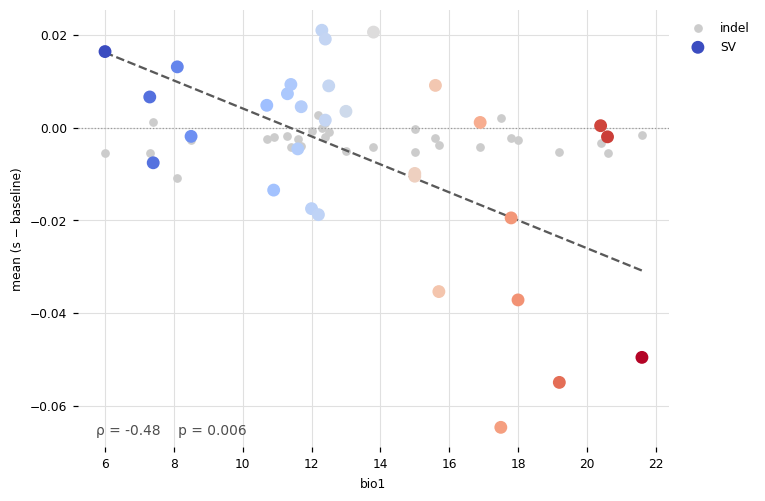

bio1: rho=-0.481 p=0.0061; SV median excess=+0.0004 (below baseline at 15/31)


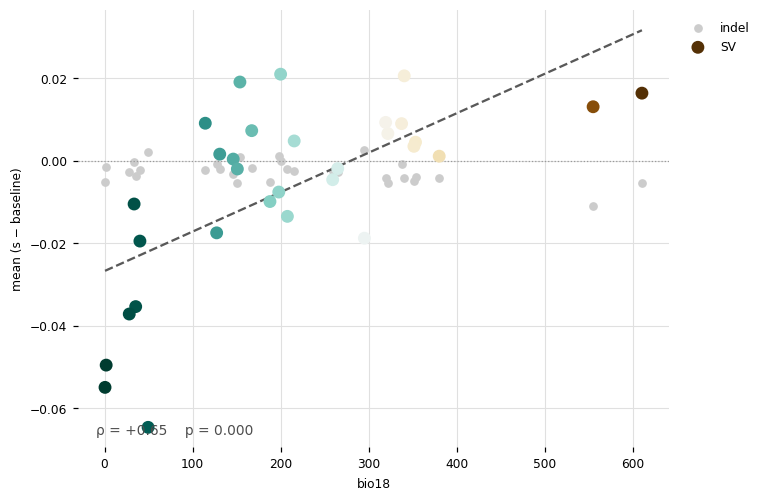

bio18: rho=+0.650 p=0.0001; SV median excess=+0.0004 (below baseline at 15/31)


In [4]:

def summary_clean(cvar, cmap):
    m = meta
    fig, ax = plt.subplots(figsize=(7, 4.6))
    ax.set_axisbelow(True); ax.grid(color="0.88", lw=0.7)
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.axhline(0, color="0.6", lw=0.8, ls=":")
    ax.scatter(m[cvar], m.shift_ind, c="0.8", s=22, label="indel")
    ax.scatter(m[cvar], m.shift_sv, c=m[cvar], cmap=cmap, s=55, label="SV", zorder=3)
    r = stats.spearmanr(m[cvar], m.shift_sv)
    b, a0 = np.polyfit(m[cvar], m.shift_sv, 1); xs = np.array([m[cvar].min(), m[cvar].max()])
    ax.plot(xs, a0 + b*xs, color="0.35", lw=1.5, ls="--")
    ax.annotate(f"ρ = {r.statistic:+.2f}    p = {r.pvalue:.3f}", xy=(0.03, 0.03),
                xycoords="axes fraction", fontsize=9, color="0.3")
    ax.set_xlabel(cvar); ax.set_ylabel("mean (s − baseline)")
    ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1.0))
    fig.tight_layout(); fig.savefig(f"{PLOTS}/s_distribution_summary_{cvar}.png", dpi=130, bbox_inches="tight")
    plt.show()
    nneg = int((m.shift_sv<0).sum())
    print(f"{cvar}: rho={r.statistic:+.3f} p={r.pvalue:.4f}; SV median excess={m.shift_sv.median():+.4f} (below baseline at {nneg}/{len(m)})")

summary_clean("bio1", "coolwarm")
summary_clean("bio18", "BrBG_r")


**Takeaway — one finding, two faces of the same de-trended shift:**

- **Net shift is null.** SNP ≡ 0 (the baseline) and indel sits on it; SV excess-vs-SNP as a
  whole-distribution median is ≈ 0 — median **+0.0004**, negative at only **15/31 sites** (sign test
  n.s.). There is **no** uniform, genome-wide SV purifying (or favoured) excess.
- **But the shift is climate-graded.** The per-site shift goes **negative (more purged) at hot/arid
  sites and positive at cold/wet ones** (bio1 ρ ≈ −0.48, p ≈ 0.006; bio18 ρ ≈ +0.65, p < 0.001). The
  net-null above is exactly these opposite-sign sites cancelling — the gradient is the real signal,
  and the panel grid shows it concentrated in the **rare (low-$p_0$) tail** at the warm sites.
- **It's insertions.** The insertion/deletion grid shows the warm-site tail purging is carried by SV
  **insertions** (ref-relative); deletions track the SNP baseline.

Bounded by the hitchhiking and insertion-polarity caveats in the header. Finer tail localization
(ECDF-difference, shift-function), the per-variant climate-slope β, and the de-trending robustness
audit are in `SV_TEMPORAL_PURGING_SUMMARY.md`.